In [10]:
%pip install pandas openpyxl matplotlib scikit-learn seaborn matplotlib-venn

from google.colab import drive
drive.mount('/content/drive')


# Set up file paths
drive_dir = r'/content/drive/My Drive'
file_path = os.path.join(drive_dir, 'DatasetsCombinedCommonPeriodMatrix.xlsx')

import matplotlib.pyplot as plt

# Load the Excel file
df = pd.read_excel(file_path, sheet_name="DatasetsCombinedCommonPeriodMat", index_col=0)
df.reset_index(inplace=True)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
else:
    print("Date column is missing or incorrectly labeled.")




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


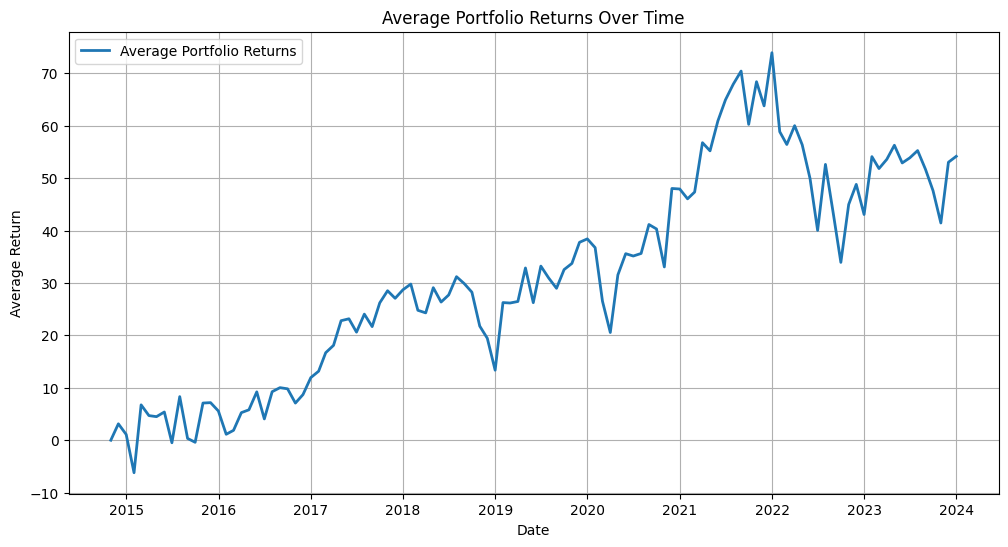

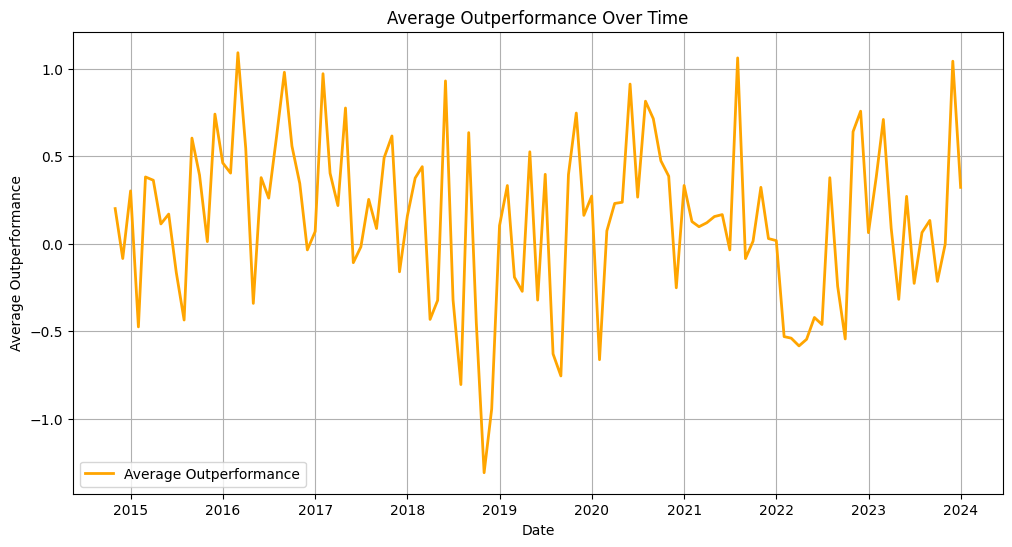

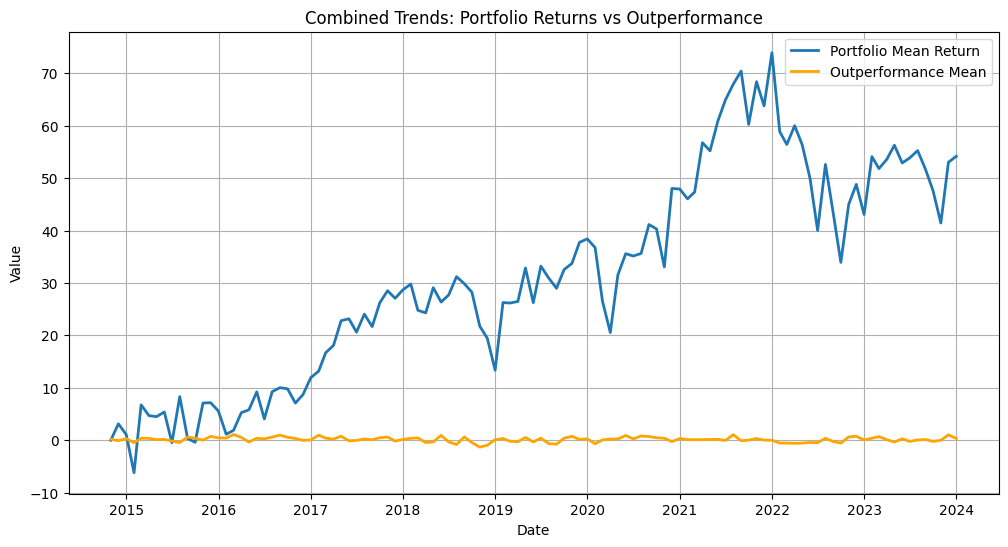

Portfolio vs Benchmark Summary:
       Valora PK - Aktien Schweiz Small and Mid Caps (Pictet).PortfolioReturnMatrix  \
count                                         111.000000                              
mean                                           52.984942                              
std                                            29.915694                              
min                                            -0.358062                              
25%                                            28.788452                              
50%                                            57.348399                              
75%                                            73.138485                              
max                                           115.300293                              

       CPEG GenÃ¨ve - Actions suisses S/M Cap (a) (GAM).PortfolioReturnMatrix  \
count                                         111.000000                        
mean                  

In [14]:
# @title Standardtext für Titel

# Ensure the 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Separate columns into portfolio returns and outperformance metrics
portfolio_return_cols = [col for col in df.columns if "PortfolioReturnMatrix" in col]
outperformance_cols = [col for col in df.columns if "OutperformanceMatrixMonthly" in col]

# Subset data for portfolio returns and outperformance
portfolio_returns = df[['Date'] + portfolio_return_cols].set_index('Date')
outperformance = df[['Date'] + outperformance_cols].set_index('Date')

# Generate summary statistics and trends for both datasets
portfolio_returns_summary = portfolio_returns.describe()
outperformance_summary = outperformance.describe()

# Generate insights over time: mean returns and outperformance trends
portfolio_mean_trend = portfolio_returns.mean(axis=1)
outperformance_mean_trend = outperformance.mean(axis=1)

# Plotting trends for portfolio returns and outperformance
plt.figure(figsize=(12, 6))
plt.plot(portfolio_mean_trend, label='Average Portfolio Returns', linewidth=2)
plt.title('Average Portfolio Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Average Return')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(outperformance_mean_trend, label='Average Outperformance', linewidth=2, color='orange')
plt.title('Average Outperformance Over Time')
plt.xlabel('Date')
plt.ylabel('Average Outperformance')
plt.legend()
plt.grid()
plt.show()

# Combine and plot correlations between portfolio returns and outperformance
combined_trends = pd.DataFrame({
    'Portfolio_Mean_Return': portfolio_mean_trend,
    'Outperformance_Mean': outperformance_mean_trend
})

plt.figure(figsize=(12, 6))
plt.plot(combined_trends['Portfolio_Mean_Return'], label='Portfolio Mean Return', linewidth=2)
plt.plot(combined_trends['Outperformance_Mean'], label='Outperformance Mean', linewidth=2, color='orange')
plt.title('Combined Trends: Portfolio Returns vs Outperformance')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

# Display portfolio vs benchmark summary
print("Portfolio vs Benchmark Summary:")
print(portfolio_vs_benchmark_summary)

# Display correlations
print("\nPortfolio-Benchmark Correlations:")
print(correlations)



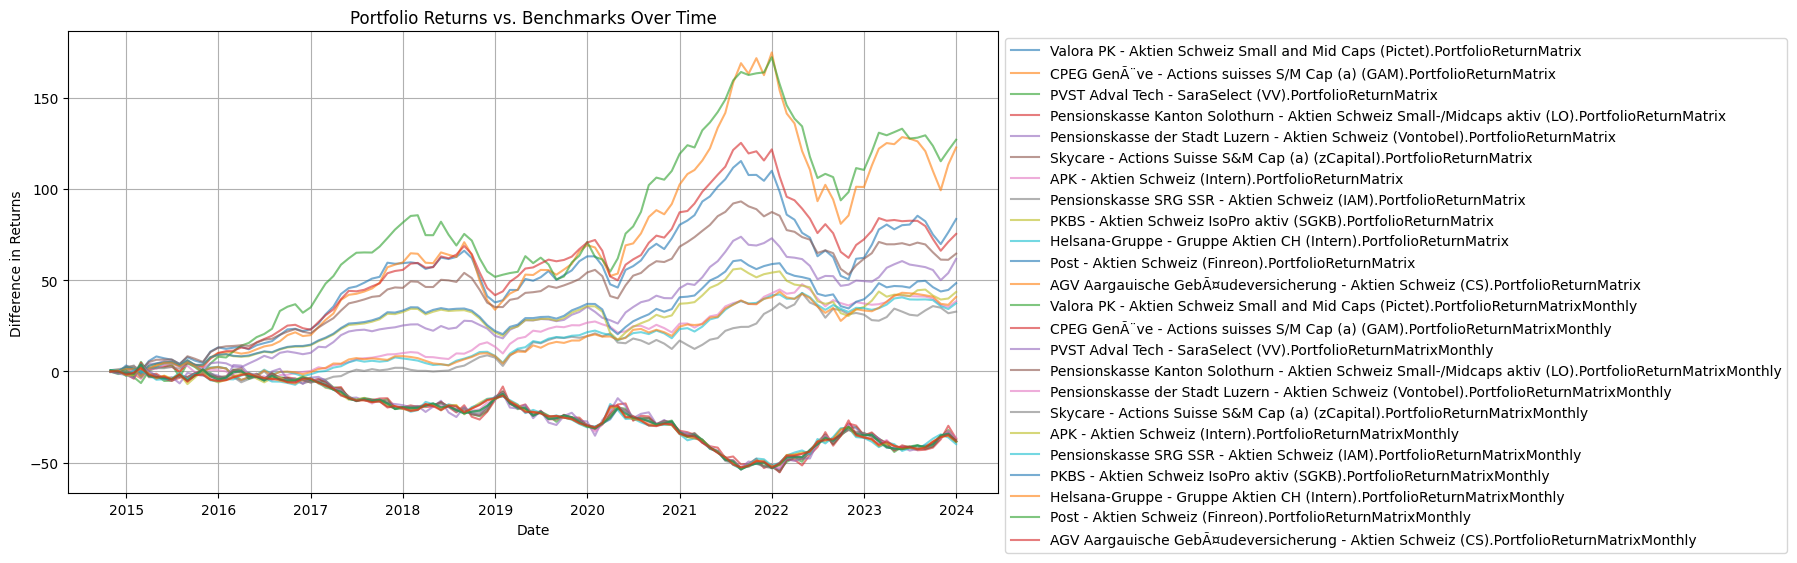

Portfolio vs Benchmark Summary:
       Valora PK - Aktien Schweiz Small and Mid Caps (Pictet).PortfolioReturnMatrix  \
count                                         111.000000                              
mean                                           52.984942                              
std                                            29.915694                              
min                                            -0.358062                              
25%                                            28.788452                              
50%                                            57.348399                              
75%                                            73.138485                              
max                                           115.300293                              

       CPEG GenÃ¨ve - Actions suisses S/M Cap (a) (GAM).PortfolioReturnMatrix  \
count                                         111.000000                        
mean                  

In [13]:
# Identify the benchmark columns
benchmark_cols = [col for col in df.columns if "Benchmark" in col]

# Extract relevant data
benchmarks = df[['Date'] + benchmark_cols].set_index('Date')

# Compare portfolio returns against benchmarks
portfolio_vs_benchmark = portfolio_returns.subtract(benchmarks.mean(axis=1), axis=0)

# Generate summary statistics for differences
portfolio_vs_benchmark_summary = portfolio_vs_benchmark.describe()

# Plot differences over time for each portfolio
plt.figure(figsize=(12, 6))
for col in portfolio_vs_benchmark.columns:
    plt.plot(portfolio_vs_benchmark.index, portfolio_vs_benchmark[col], label=col, alpha=0.6)

plt.title('Portfolio Returns vs. Benchmarks Over Time')
plt.xlabel('Date')
plt.ylabel('Difference in Returns')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.show()

# Analyze correlation between portfolio returns and benchmarks
correlations = portfolio_returns.corrwith(benchmarks.mean(axis=1))

# Display portfolio vs benchmark summary
print("Portfolio vs Benchmark Summary:")
print(portfolio_vs_benchmark_summary)

# Display correlations
print("\nPortfolio-Benchmark Correlations:")
print(correlations)
